In [1]:
import pandas as pd 
import numpy as np

In [2]:
data = pd.read_excel("PGCB_date_power_demand.xlsx")

In [3]:
weather_details = pd.read_excel("weather_data.xlsx",nrows=1)
weather_details_dict = weather_details.iloc[0].to_dict()
weather = pd.read_excel("weather_data.xlsx", skiprows=3)

In [4]:
economic = pd.read_csv("economic_full_1.csv")

In [5]:
data.columns


Index(['datetime', 'generation_mw', 'demand_mw', 'load_shedding', 'gas',
       'liquid_fuel', 'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc',
       'india_tripura', 'india_adani', 'nepal', 'remarks'],
      dtype='object')

In [6]:
data['datetime'] = pd.to_datetime(data['datetime'])
data = data.sort_values('datetime')
data = data.drop_duplicates(subset=['datetime'])

In [7]:
data.shape

(92218, 15)

In [8]:
data.set_index('datetime', inplace=True)

In [9]:
def weighted_resample(group):
    if len(group) == 2:
        return np.average(group, weights=[0.8, 0.2])
    elif len(group) == 1:
        return group.iloc[0]
    return np.nan

In [10]:
data_hourly = data[['demand_mw']].resample('h').apply(weighted_resample)

In [11]:
data_hourly = data_hourly.ffill()

In [12]:
import matplotlib.pyplot as plt

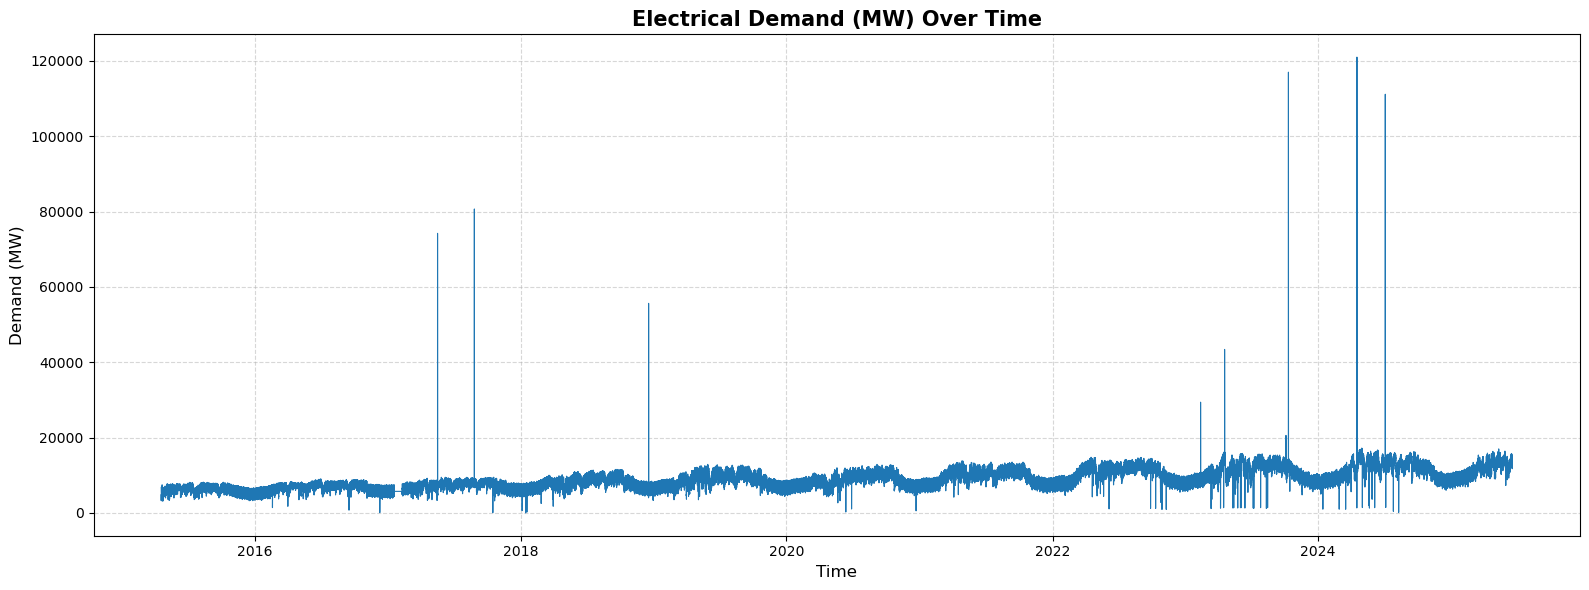

In [13]:
data_hourly = data_hourly.sort_index()
plt.figure(figsize=(16, 6))
plt.plot(data_hourly.index, data_hourly['demand_mw'], color='#1f77b4', linewidth=0.8)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.title('Electrical Demand (MW) Over Time', fontsize=15, fontweight='bold')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Demand (MW)', fontsize=12)
plt.tight_layout()
plt.show()

In [14]:
Q1 = data_hourly['demand_mw'].quantile(0.25)
Q3 = data_hourly['demand_mw'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
data_hourly['is_outlier'] = np.where((data_hourly['demand_mw'] < lower_bound) | (data_hourly['demand_mw'] > upper_bound), 1, 0)
data_hourly.loc[data_hourly['is_outlier'] == 1, 'demand_mw'] = np.nan
data_hourly['demand_mw'] = data_hourly['demand_mw'].interpolate(method='time')
data_hourly.drop(columns=['is_outlier'], inplace=True)

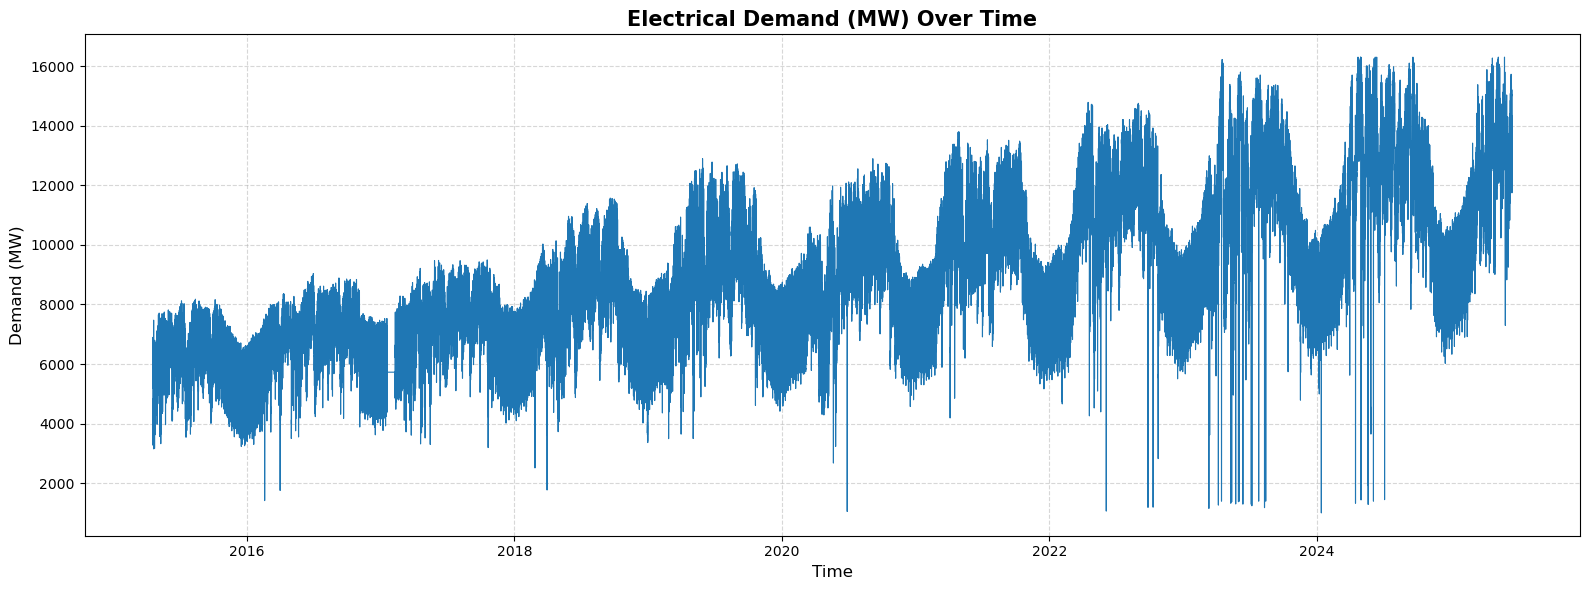

In [15]:
plt.figure(figsize=(16, 6))
plt.plot(data_hourly.index, data_hourly['demand_mw'], color='#1f77b4', linewidth=0.8)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.title('Electrical Demand (MW) Over Time', fontsize=15, fontweight='bold')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Demand (MW)', fontsize=12)
plt.tight_layout()
plt.show()

In [16]:
weather.head()

,time,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s)
0,2014-01-01 00:00:00,13.9,89,13.3,0.0,12.1,16.4,313,0,0.0
1,2014-01-01 01:00:00,13.6,91,13.2,0.0,12.1,16.0,317,0,0.0
2,2014-01-01 02:00:00,13.3,91,12.8,0.0,11.9,15.7,317,0,0.0
3,2014-01-01 03:00:00,13.0,92,12.5,0.0,11.8,15.4,319,0,0.0
4,2014-01-01 04:00:00,12.7,93,12.2,0.0,11.6,15.2,322,0,0.0


In [17]:
weather.columns

Index(['time', 'temperature_2m (°C)', 'relative_humidity_2m (%)',
       'apparent_temperature (°C)', 'precipitation (mm)', 'dew_point_2m (°C)',
       'soil_temperature_0_to_7cm (°C)', 'wind_direction_10m (°)',
       'cloud_cover (%)', 'sunshine_duration (s)'],
      dtype='object')

In [18]:
weather['time'] = pd.to_datetime(weather['time'])
weather.set_index('time', inplace=True)

In [19]:
weather_hourly = weather.resample('h').mean().ffill()

In [20]:
df = data_hourly.join(weather_hourly, how='left')
df = df.ffill()

In [21]:
df.head()

,demand_mw,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s)
datetime,,,,,,,,,,
2015-04-19 00:00:00,4821.0,25.7,87.0,29.6,0.0,23.5,26.7,188.0,9.0,0.0
2015-04-19 01:00:00,3612.0,25.3,88.0,30.0,0.0,23.2,26.4,151.0,26.0,0.0
2015-04-19 02:00:00,3727.0,24.9,90.0,29.6,0.0,23.2,26.1,152.0,32.0,0.0
2015-04-19 03:00:00,3632.0,25.0,90.0,29.3,0.0,23.3,26.1,171.0,30.0,0.0
2015-04-19 04:00:00,3641.0,25.2,91.0,30.3,0.0,23.5,26.0,184.0,67.0,0.0


In [22]:
economic.columns

Index(['Country Name', 'Indicator Name', 'Indicator Code', '1960', '1961',
       '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '1970',
       '1971', '1972', '1973', '1974', '1975', '1976', '1977', '1978', '1979',
       '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988',
       '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997',
       '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006',
       '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015',
       '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024',
       '2025'],
      dtype='object')

In [23]:
cols_to_drop = ['Country Name', 'Indicator Code']
economic_clean = economic.drop(columns=cols_to_drop, errors='ignore')
economic_clean.set_index('Indicator Name', inplace=True)
economic_t = economic_clean.T
economic_t.index.name = 'Year'
economic_t = economic_t.reset_index()
economic_t['Year'] = pd.to_numeric(economic_t['Year'], errors='coerce')
economic_t.dropna(subset=['Year'], inplace=True)
economic_t['Year'] = economic_t['Year'].astype(int)
economic_t.set_index('Year', inplace=True)
economic_t = economic_t.ffill().reset_index()

In [24]:
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['is_weekend'] = np.where(df.index.dayofweek >= 5, 1, 0)

In [25]:
df.head()

,demand_mw,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s),hour,day_of_week,month,is_weekend
datetime,,,,,,,,,,,,,,
2015-04-19 00:00:00,4821.0,25.7,87.0,29.6,0.0,23.5,26.7,188.0,9.0,0.0,0,6,4,1
2015-04-19 01:00:00,3612.0,25.3,88.0,30.0,0.0,23.2,26.4,151.0,26.0,0.0,1,6,4,1
2015-04-19 02:00:00,3727.0,24.9,90.0,29.6,0.0,23.2,26.1,152.0,32.0,0.0,2,6,4,1
2015-04-19 03:00:00,3632.0,25.0,90.0,29.3,0.0,23.3,26.1,171.0,30.0,0.0,3,6,4,1
2015-04-19 04:00:00,3641.0,25.2,91.0,30.3,0.0,23.5,26.0,184.0,67.0,0.0,4,6,4,1


In [26]:
df['Year'] = df.index.year

In [27]:
datetime_col_name = df.index.name 
df = df.reset_index()
df = pd.merge(df, economic_t, on='Year', how='left')
df.set_index(datetime_col_name, inplace=True)
df.drop(columns=['Year'], inplace=True)

In [28]:
df.head()


,demand_mw,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s),...,Present value of external debt (current US$),Short-term debt (% of total external debt),"External debt stocks, public and publicly guaranteed (PPG) (DOD, current US$)",External debt stocks (% of GNI),"Net ODA provided, total (current US$)","Net bilateral aid flows from DAC donors, Total (current US$)","Net bilateral aid flows from DAC donors, Portugal (current US$)","Net bilateral aid flows from DAC donors, Netherlands (current US$)","Net bilateral aid flows from DAC donors, Japan (current US$)","Net bilateral aid flows from DAC donors, Hungary (current US$)"
datetime,,,,,,,,,,,,,,,,,,,,,
2015-04-19 00:00:00,4821.0,25.7,87.0,29.6,0.0,23.5,26.7,188.0,9.0,0.0,...,NaN,17.1025,2.716974e+10,18.656465,NaN,1.279995e+09,NaN,46602249.15,375160003.7,5115.000065
2015-04-19 01:00:00,3612.0,25.3,88.0,30.0,0.0,23.2,26.4,151.0,26.0,0.0,...,NaN,17.1025,2.716974e+10,18.656465,NaN,1.279995e+09,NaN,46602249.15,375160003.7,5115.000065
2015-04-19 02:00:00,3727.0,24.9,90.0,29.6,0.0,23.2,26.1,152.0,32.0,0.0,...,NaN,17.1025,2.716974e+10,18.656465,NaN,1.279995e+09,NaN,46602249.15,375160003.7,5115.000065
2015-04-19 03:00:00,3632.0,25.0,90.0,29.3,0.0,23.3,26.1,171.0,30.0,0.0,...,NaN,17.1025,2.716974e+10,18.656465,NaN,1.279995e+09,NaN,46602249.15,375160003.7,5115.000065
2015-04-19 04:00:00,3641.0,25.2,91.0,30.3,0.0,23.5,26.0,184.0,67.0,0.0,...,NaN,17.1025,2.716974e+10,18.656465,NaN,1.279995e+09,NaN,46602249.15,375160003.7,5115.000065


In [29]:
df['lag_1h'] = df['demand_mw'].shift(1)
df['lag_2h'] = df['demand_mw'].shift(2)
df['lag_24h'] = df['demand_mw'].shift(24)

In [30]:
df.head()

,demand_mw,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s),...,External debt stocks (% of GNI),"Net ODA provided, total (current US$)","Net bilateral aid flows from DAC donors, Total (current US$)","Net bilateral aid flows from DAC donors, Portugal (current US$)","Net bilateral aid flows from DAC donors, Netherlands (current US$)","Net bilateral aid flows from DAC donors, Japan (current US$)","Net bilateral aid flows from DAC donors, Hungary (current US$)",lag_1h,lag_2h,lag_24h
datetime,,,,,,,,,,,,,,,,,,,,,
2015-04-19 00:00:00,4821.0,25.7,87.0,29.6,0.0,23.5,26.7,188.0,9.0,0.0,...,18.656465,NaN,1.279995e+09,NaN,46602249.15,375160003.7,5115.000065,NaN,NaN,NaN
2015-04-19 01:00:00,3612.0,25.3,88.0,30.0,0.0,23.2,26.4,151.0,26.0,0.0,...,18.656465,NaN,1.279995e+09,NaN,46602249.15,375160003.7,5115.000065,4821.0,NaN,NaN
2015-04-19 02:00:00,3727.0,24.9,90.0,29.6,0.0,23.2,26.1,152.0,32.0,0.0,...,18.656465,NaN,1.279995e+09,NaN,46602249.15,375160003.7,5115.000065,3612.0,4821.0,NaN
2015-04-19 03:00:00,3632.0,25.0,90.0,29.3,0.0,23.3,26.1,171.0,30.0,0.0,...,18.656465,NaN,1.279995e+09,NaN,46602249.15,375160003.7,5115.000065,3727.0,3612.0,NaN
2015-04-19 04:00:00,3641.0,25.2,91.0,30.3,0.0,23.5,26.0,184.0,67.0,0.0,...,18.656465,NaN,1.279995e+09,NaN,46602249.15,375160003.7,5115.000065,3632.0,3727.0,NaN


In [31]:
df['rolling_3h'] = df['demand_mw'].shift(1).rolling(window=3).mean()
df['rolling_24h'] = df['demand_mw'].shift(1).rolling(window=24).mean()
df.head()

,demand_mw,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s),...,"Net bilateral aid flows from DAC donors, Total (current US$)","Net bilateral aid flows from DAC donors, Portugal (current US$)","Net bilateral aid flows from DAC donors, Netherlands (current US$)","Net bilateral aid flows from DAC donors, Japan (current US$)","Net bilateral aid flows from DAC donors, Hungary (current US$)",lag_1h,lag_2h,lag_24h,rolling_3h,rolling_24h
datetime,,,,,,,,,,,,,,,,,,,,,
2015-04-19 00:00:00,4821.0,25.7,87.0,29.6,0.0,23.5,26.7,188.0,9.0,0.0,...,1.279995e+09,NaN,46602249.15,375160003.7,5115.000065,NaN,NaN,NaN,NaN,NaN
2015-04-19 01:00:00,3612.0,25.3,88.0,30.0,0.0,23.2,26.4,151.0,26.0,0.0,...,1.279995e+09,NaN,46602249.15,375160003.7,5115.000065,4821.0,NaN,NaN,NaN,NaN
2015-04-19 02:00:00,3727.0,24.9,90.0,29.6,0.0,23.2,26.1,152.0,32.0,0.0,...,1.279995e+09,NaN,46602249.15,375160003.7,5115.000065,3612.0,4821.0,NaN,NaN,NaN
2015-04-19 03:00:00,3632.0,25.0,90.0,29.3,0.0,23.3,26.1,171.0,30.0,0.0,...,1.279995e+09,NaN,46602249.15,375160003.7,5115.000065,3727.0,3612.0,NaN,4053.333333,NaN
2015-04-19 04:00:00,3641.0,25.2,91.0,30.3,0.0,23.5,26.0,184.0,67.0,0.0,...,1.279995e+09,NaN,46602249.15,375160003.7,5115.000065,3632.0,3727.0,NaN,3657.000000,NaN


In [32]:
df['demand_plus+1hr'] = df['demand_mw'].shift(-1)
df.head()

,demand_mw,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s),...,"Net bilateral aid flows from DAC donors, Portugal (current US$)","Net bilateral aid flows from DAC donors, Netherlands (current US$)","Net bilateral aid flows from DAC donors, Japan (current US$)","Net bilateral aid flows from DAC donors, Hungary (current US$)",lag_1h,lag_2h,lag_24h,rolling_3h,rolling_24h,demand_plus+1hr
datetime,,,,,,,,,,,,,,,,,,,,,
2015-04-19 00:00:00,4821.0,25.7,87.0,29.6,0.0,23.5,26.7,188.0,9.0,0.0,...,NaN,46602249.15,375160003.7,5115.000065,NaN,NaN,NaN,NaN,NaN,3612.0
2015-04-19 01:00:00,3612.0,25.3,88.0,30.0,0.0,23.2,26.4,151.0,26.0,0.0,...,NaN,46602249.15,375160003.7,5115.000065,4821.0,NaN,NaN,NaN,NaN,3727.0
2015-04-19 02:00:00,3727.0,24.9,90.0,29.6,0.0,23.2,26.1,152.0,32.0,0.0,...,NaN,46602249.15,375160003.7,5115.000065,3612.0,4821.0,NaN,NaN,NaN,3632.0
2015-04-19 03:00:00,3632.0,25.0,90.0,29.3,0.0,23.3,26.1,171.0,30.0,0.0,...,NaN,46602249.15,375160003.7,5115.000065,3727.0,3612.0,NaN,4053.333333,NaN,3641.0
2015-04-19 04:00:00,3641.0,25.2,91.0,30.3,0.0,23.5,26.0,184.0,67.0,0.0,...,NaN,46602249.15,375160003.7,5115.000065,3632.0,3727.0,NaN,3657.000000,NaN,3283.0


In [33]:
check_data= int(len(df) * 0.70) 
df.dropna(axis=1, thresh=check_data, inplace=True)
df = df.ffill()
df.dropna(axis=0, inplace=True)
df.shape

(65389, 1406)

In [34]:
df.dropna(inplace=True)
df.shape

(65389, 1406)

In [35]:
df['demand_change_1h'] = df['lag_1h'] - df['lag_2h']
if 'temperature_2m (°C)' in df.columns:
    df['temp_lag_1h'] = df['temperature_2m (°C)'].shift(1)
    df['temp_lag_3h'] = df['temperature_2m (°C)'].shift(3)
df['is_peak_hour'] = df['hour'].apply(lambda x: 1 if 18 <= x <= 22 else 0)
df.dropna(inplace=True)

In [36]:
train_df = df.loc[df.index.year <= 2023].copy()
test_df = df.loc[df.index.year == 2024].copy()


In [37]:
train_df.shape

(52581, 1410)

In [38]:
test_df.shape

(8784, 1410)

In [39]:
features = [col for col in df.columns if col != 'demand_plus+1hr']


In [40]:
train_df.head()

,demand_mw,temperature_2m (°C),relative_humidity_2m (%),apparent_temperature (°C),precipitation (mm),dew_point_2m (°C),soil_temperature_0_to_7cm (°C),wind_direction_10m (°),cloud_cover (%),sunshine_duration (s),...,lag_1h,lag_2h,lag_24h,rolling_3h,rolling_24h,demand_plus+1hr,demand_change_1h,temp_lag_1h,temp_lag_3h,is_peak_hour
datetime,,,,,,,,,,,,,,,,,,,,,
2018-01-01 03:00:00,4599.0,13.8,92.0,13.2,0.0,12.6,16.8,316.0,95.0,0.0,...,4786.0,4908.0,7590.0,4959.000000,6336.075000,4594.0,-122.0,14.1,14.9,0
2018-01-01 04:00:00,4594.0,13.9,92.0,13.7,0.0,12.6,16.5,290.0,43.0,0.0,...,4599.0,4786.0,7590.0,4764.333333,6211.450000,4862.0,-187.0,13.8,14.6,0
2018-01-01 05:00:00,4862.0,12.9,96.0,12.6,0.0,12.3,16.2,289.0,87.0,0.0,...,4594.0,4599.0,7590.0,4659.666667,6086.616667,5191.0,-5.0,13.9,14.1,0
2018-01-01 06:00:00,5191.0,13.6,98.0,13.6,0.0,13.2,17.8,325.0,100.0,0.0,...,4862.0,4594.0,7590.0,4685.000000,5972.950000,5595.0,268.0,12.9,13.8,0
2018-01-01 07:00:00,5595.0,14.1,98.0,14.2,0.0,13.8,17.4,337.0,77.0,0.0,...,5191.0,4862.0,5490.0,4882.333333,5872.991667,5927.0,329.0,13.6,13.9,0


In [41]:
X_train = train_df[features]
y_train = train_df['demand_plus+1hr']

X_test = test_df[features]
y_test = test_df['demand_plus+1hr']

In [42]:
import xgboost as xgb
model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    objective='reg:squarederror'
)

In [43]:
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [44]:
predictions = model.predict(X_test)

In [45]:
from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(y_test, predictions)
print(f"MAPE: {mape * 100:.2f}%")

MAPE: 2.77%


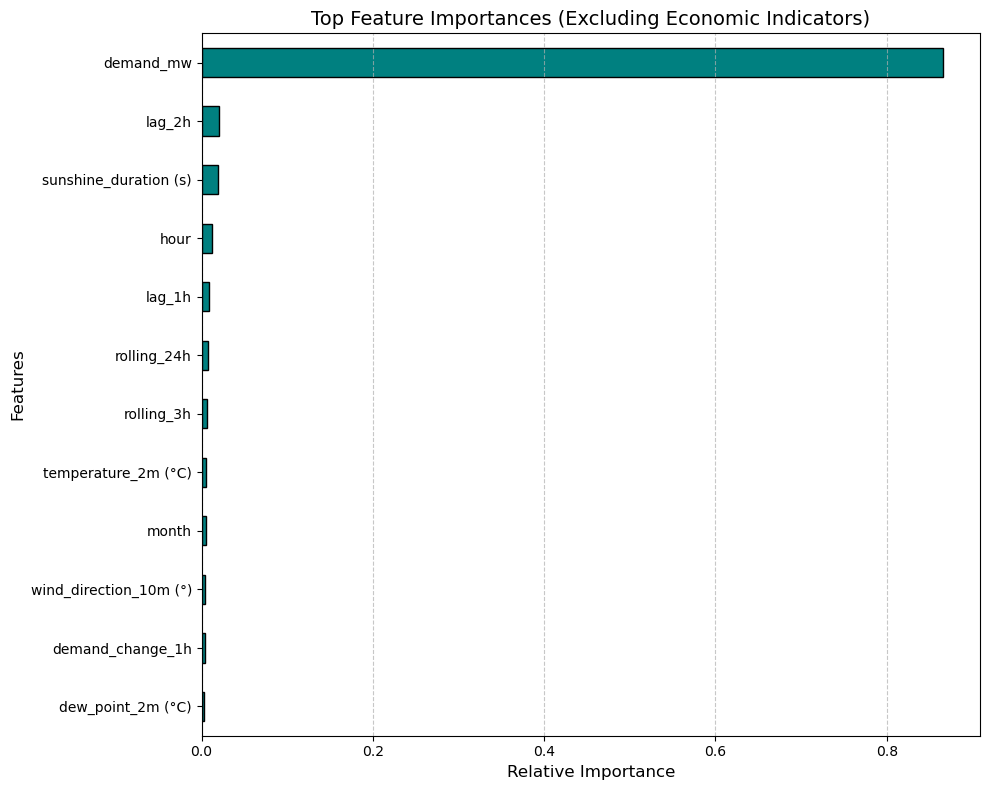

In [46]:


importances = pd.Series(model.feature_importances_, index=X_train.columns)
economic_keywords = ['export', 'import', 'merchandise', 'account', 'financial', 'income', 'gdp', 'inflation', 'labor', 'bank']
pattern = '|'.join(economic_keywords)
is_not_economic = ~importances.index.str.lower().str.contains(pattern)
curated_importances = importances[is_not_economic]
top_features = curated_importances.sort_values().tail(12) 
plt.figure(figsize=(10, 8))
top_features.plot(kind='barh', color='teal', edgecolor='black')
plt.title('Top Feature Importances (Excluding Economic Indicators)', fontsize=14)
plt.xlabel('Relative Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

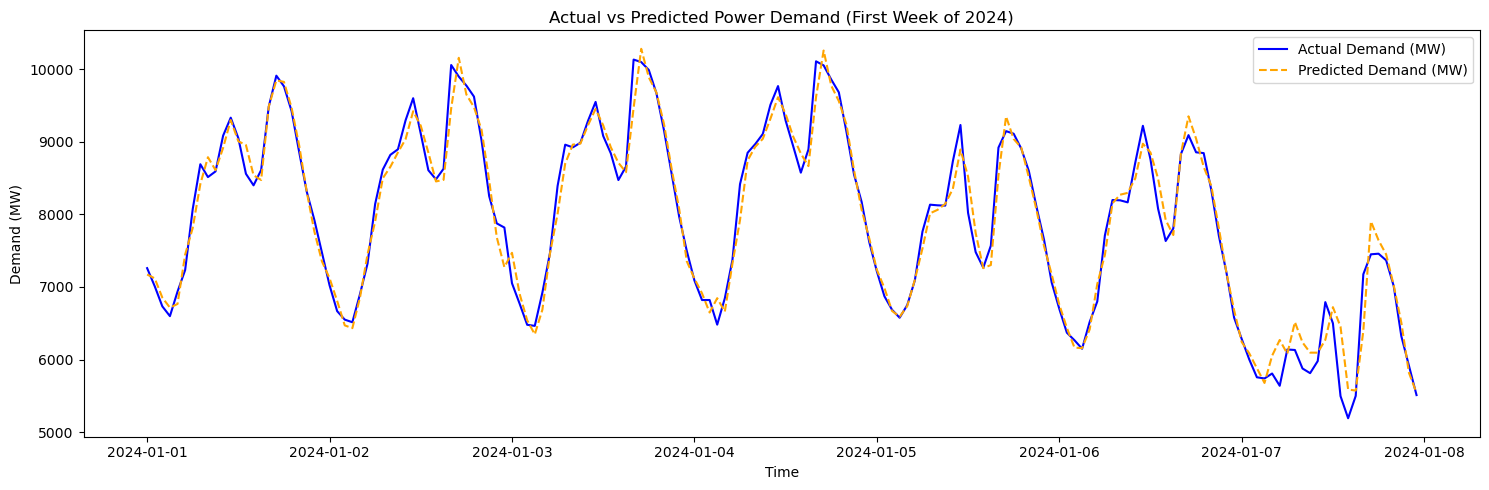

In [47]:
plt.figure(figsize=(15, 5))
plt.plot(y_test.index[:168], y_test.values[:168], label='Actual Demand (MW)', color='blue')
plt.plot(y_test.index[:168], predictions[:168], label='Predicted Demand (MW)', color='orange', linestyle='--')
plt.title('Actual vs Predicted Power Demand (First Week of 2024)')
plt.xlabel('Time')
plt.ylabel('Demand (MW)')
plt.legend()
plt.tight_layout()
plt.show()

In [48]:
import lightgbm as lgb

In [49]:
import re
X_train = X_train.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '_', x))
X_test = X_test.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '_', x))
lgbm_model = lgb.LGBMRegressor(n_estimators=400,learning_rate=0.05,max_depth=8,num_leaves=31,subsample=0.8,colsample_bytree=1,random_state=42,
                               n_jobs=-1,verbose=-1)
lgbm_model.fit(X_train,y_train)
lgbm_predictions = lgbm_model.predict(X_test)
lgbm_mape = mean_absolute_percentage_error(y_test, lgbm_predictions)
print(f"LightGBM MAPE: {lgbm_mape * 100:.2f}%")


LightGBM MAPE: 2.61%


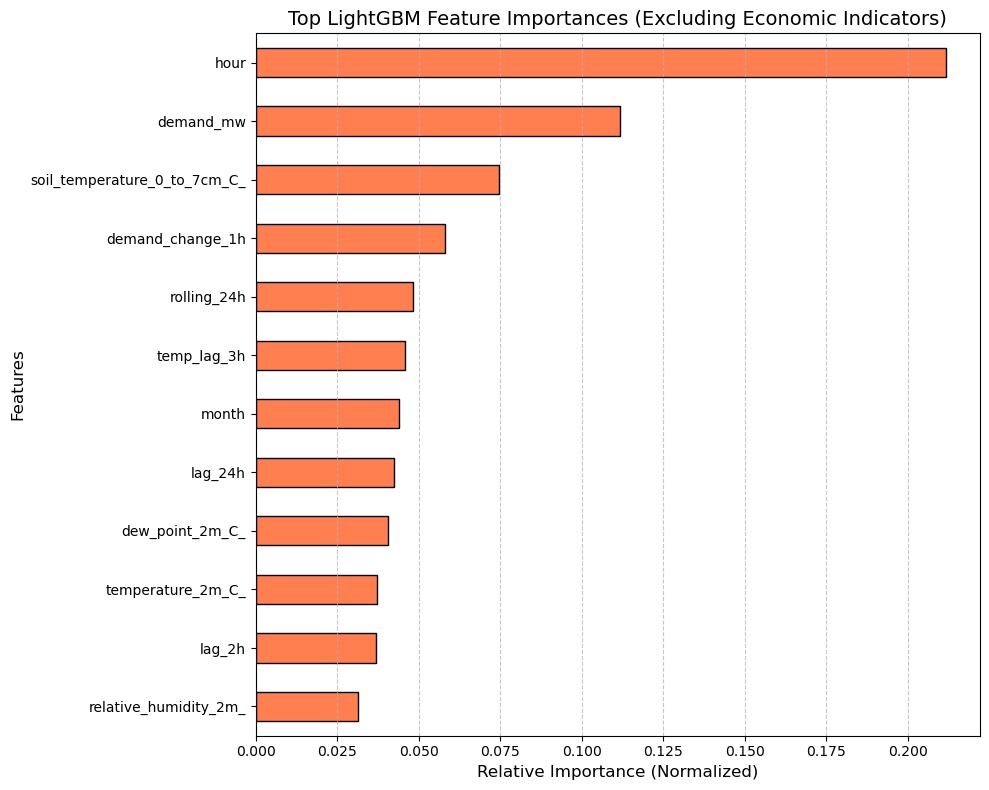

In [50]:
lgbm_importances = pd.Series(lgbm_model.feature_importances_, index=X_train.columns)
lgbm_importances = lgbm_importances / lgbm_importances.sum()
economic_keywords = ['export', 'import', 'merchandise', 'account', 'financial', 'income', 'gdp', 'inflation', 'labor', 'bank']
pattern = '|'.join(economic_keywords)
is_not_economic = ~lgbm_importances.index.str.lower().str.contains(pattern)
curated_lgbm_importances = lgbm_importances[is_not_economic]
top_lgbm_features = curated_lgbm_importances.sort_values().tail(12)
plt.figure(figsize=(10, 8))
top_lgbm_features.plot(kind='barh', color='coral', edgecolor='black')
plt.title('Top LightGBM Feature Importances (Excluding Economic Indicators)', fontsize=14)
plt.xlabel('Relative Importance (Normalized)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7) 
plt.tight_layout()
plt.show()

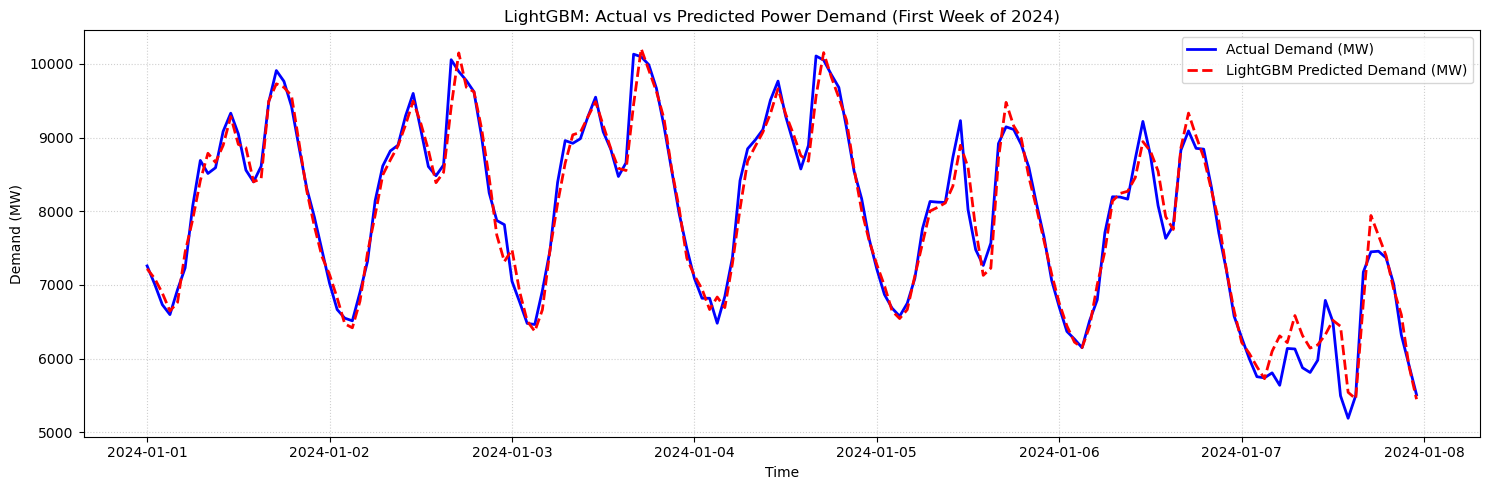

In [51]:
window_size = 168 
plt.figure(figsize=(15, 5))
plt.plot(y_test.index[:window_size], y_test.values[:window_size], label='Actual Demand (MW)', color='blue', linewidth=2)
plt.plot(y_test.index[:window_size], lgbm_predictions[:window_size], label='LightGBM Predicted Demand (MW)', color='red', linestyle='--', linewidth=2)
plt.title('LightGBM: Actual vs Predicted Power Demand (First Week of 2024)')
plt.xlabel('Time')
plt.ylabel('Demand (MW)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [52]:
print("LightGBM beats XGBoost in terms of MAPE (2.61% vs 2.77%) and is now the better model to predict the electricity demand ")

LightGBM beats XGBoost in terms of MAPE (2.61% vs 2.77%) and is now the better model to predict the electricity demand 
